<a href="https://colab.research.google.com/github/fatimatouh/fatimatouh.github.io/blob/main/mobilite_dakar.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## **ETAPE 1 : Génération des Données Simulées **

In [ ]:
!pip install faker pandera

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 21.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 303.6/303.6 kB 10.1 MB/s eta 0:00:00


In [ ]:
import pandas as pd
import numpy as np
from faker import Faker
import random
from datetime import datetime, timedelta
import pandera as pa
from google.colab import files

In [ ]:
# Initialisation
fake = Faker('fr_FR')

CONFIG = {
    'N_VEHICULES_BUS': 20, 'N_VEHICULES_TAXI': 50, 'N_VEHICULES_PARTICULIER': 100,
    'N_JOURS_SIMULATION': 1, 'POINTS_PAR_TRAJET_MIN': 20, 'POINTS_PAR_TRAJET_MAX': 50,
    'START_DATETIME': datetime(2024, 3, 1, 6, 0, 0),
    'HEURES_POINTE': [(7, 9), (17, 19)],
    'N_INCIDENTS_PAR_JOUR_MIN': 5, 'N_INCIDENTS_PAR_JOUR_MAX': 10,
}

DAKAR_ZONES_COORDS = {
    "Plateau": (14.66, 14.68, -17.44, -17.42), "Medina": (14.68, 14.70, -17.46, -17.44),
    "Grand Dakar": (14.70, 14.72, -17.45, -17.43), "HLM": (14.71, 14.73, -17.44, -17.42),
    "Yoff": (14.74, 14.76, -17.49, -17.47), "Pikine": (14.75, 14.77, -17.40, -17.38),
}

ROUTES_SIMPLIFIEES = [
    ["Yoff", "HLM", "Plateau"], ["Pikine", "Grand Dakar", "Medina", "Plateau"],
    ["Plateau", "Medina", "HLM"], ["Yoff", "Pikine", "Grand Dakar"],
]

def generate_zone_coords(coords):
    return round(random.uniform(coords[0], coords[1]), 6), round(random.uniform(coords[2], coords[3]), 6)

# 1. GÉNÉRATION DES ZONES
print("1/3 - Génération des zones...")
zones = [{'zone_id': i, 'nom_zone': n, 'latitude_centre': (c[0]+c[1])/2, 'longitude_centre': (c[2]+c[3])/2}
         for i, (n, c) in enumerate(DAKAR_ZONES_COORDS.items(), 1)]
df_zones = pd.DataFrame(zones)
df_zones.to_csv('zones_interet_dakar.csv', index=False)

# 2. GÉNÉRATION DES TRAJETS
print("2/3 - Génération des trajets...")
trajets = []
vehicules = [{'id': f"BUS_{i}", 'type': 'Bus'} for i in range(20)] + \
            [{'id': f"TAXI_{i}", 'type': 'Taxi'} for i in range(50)] + \
            [{'id': f"PART_{i}", 'type': 'Particulier'} for i in range(100)]

for veh in vehicules:
    route = random.choice(ROUTES_SIMPLIFIEES)
    time = CONFIG['START_DATETIME'] + timedelta(minutes=random.randint(0, 300))
    for i in range(len(route)-1):
        lat, lon = generate_zone_coords(DAKAR_ZONES_COORDS[route[i]])
        for _ in range(random.randint(20, 40)):
            trajets.append({'vehicule_id': veh['id'], 'timestamp': time.strftime('%Y-%m-%d %H:%M:%S'),
                            'latitude': lat, 'longitude': lon, 'type_vehicule': veh['type']})
            lat += random.uniform(-0.0005, 0.0005)
            lon += random.uniform(-0.0005, 0.0005)
            time += timedelta(seconds=random.randint(30, 60))
pd.DataFrame(trajets).to_csv('trajets_vehicules_dakar.csv', index=False)

1/3 - Génération des zones...
2/3 - Génération des trajets...


In [ ]:
# 3. GÉNÉRATION DES INCIDENTS
print("3/3 - Génération des incidents...")
incidents = []
for i in range(10):
    zone = random.choice(list(DAKAR_ZONES_COORDS.keys()))
    lat, lon = generate_zone_coords(DAKAR_ZONES_COORDS[zone])
    start = CONFIG['START_DATETIME'] + timedelta(minutes=random.randint(0, 1200))
    incidents.append({'incident_id': f"INC_{i}", 'timestamp_debut': start.strftime('%Y-%m-%d %H:%M:%S'),
                      'latitude': lat, 'longitude': lon, 'type_incident': random.choice(['Accident', 'Travaux']),
                      'severite': random.randint(1, 5)})
pd.DataFrame(incidents).to_csv('incidents_trafic_dakar.csv', index=False)

print("\nTerminé ! Téléchargement des fichiers...")
files.download('zones_interet_dakar.csv')
files.download('trajets_vehicules_dakar.csv')
files.download('incidents_trafic_dakar.csv')

3/3 - Génération des incidents...

Terminé ! Téléchargement des fichiers...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
df_zones.head()

,zone_id,nom_zone,latitude_centre,longitude_centre
0,1,Plateau,14.67,-17.43
1,2,Medina,14.69,-17.45
2,3,Grand Dakar,14.71,-17.44
3,4,HLM,14.72,-17.43
4,5,Yoff,14.75,-17.48


In [ ]:
df_trajets = pd.DataFrame(trajets)
df_trajets.head()

,vehicule_id,timestamp,latitude,longitude,type_vehicule
0,BUS_0,2024-03-01 07:41:00,14.759057,-17.484867,Bus
1,BUS_0,2024-03-01 07:41:54,14.758982,-17.484472,Bus
2,BUS_0,2024-03-01 07:42:27,14.759086,-17.484289,Bus
3,BUS_0,2024-03-01 07:43:10,14.758607,-17.483885,Bus
4,BUS_0,2024-03-01 07:44:04,14.758129,-17.483797,Bus


# **ETAPE 2 : Ingestion avec Apache NiFi (simulation)**

In [ ]:
# simulate_nifi_hdfs.py
import os, shutil

# Créer la structure HDFS simulée
base = '/content/hdfs_simulation/user/equipeX_mobilite/brut'
for folder in ['zones', 'trajets', 'incidents']:
    os.makedirs(f'{base}/{folder}', exist_ok=True)

# Copier les CSV (simule PutHDFS)
shutil.copy('zones_interet_dakar.csv',    f'{base}/zones/')
shutil.copy('trajets_vehicules_dakar.csv', f'{base}/trajets/')
shutil.copy('incidents_trafic_dakar.csv',  f'{base}/incidents/')

# Vérification (simule : hdfs dfs -ls)
for root, dirs, files in os.walk(base):
    level = root.replace(base, '').count(os.sep)
    indent = ' ' * 2 * level
    print(f'{indent}{os.path.basename(root)}/')
    for f in files:
        size = os.path.getsize(os.path.join(root, f))
        print(f'{indent}  {f}  ({size:,} bytes)')
print('\n Structure HDFS simulée créée avec succès !')

brut/
  trajets/
    trajets_vehicules_dakar.csv  (827,279 bytes)
  zones/
    zones_interet_dakar.csv  (222 bytes)
  incidents/
    incidents_trafic_dakar.csv  (644 bytes)

 Structure HDFS simulée créée avec succès !


In [ ]:
import os

base = '/content/hdfs_simulation/user/equipeX_mobilite/brut'

print('Structure HDFS simulée :')
for root, dirs, files in os.walk(base):
    level = root.replace(base, '').count(os.sep)
    indent = ' ' * 2 * level
    print(f'{indent}{os.path.basename(root)}/')
    for f in files:
        size = os.path.getsize(os.path.join(root, f))
        print(f'{indent}  {f}  ({size:,} bytes)}}')


Structure HDFS simulée :
brut/
  trajets/
    trajets_vehicules_dakar.csv  (812,079 bytes)}
  zones/
    zones_interet_dakar.csv  (222 bytes)}
  incidents/
    incidents_trafic_dakar.csv  (645 bytes)}


# **ÉTAPE 3 : Tables Hive & Transformations Spark**

In [ ]:
!pip install pyspark -q
!pip install findspark -q
print('PySpark installé !')

PySpark installé !


In [ ]:
from pyspark.sql import SparkSession

spark = SparkSession.builder \
    .appName('EquipeX_Mobilite_Prep') \
    .config('spark.sql.warehouse.dir', '/content/spark_warehouse') \
    .getOrCreate()

spark.sparkContext.setLogLevel('ERROR')
print('SparkSession démarrée !')
print(f'Spark version : {spark.version}')


SparkSession démarrée !
Spark version : 4.0.2


In [ ]:
# Charge les 3 fichiers CSV dans Spark
df_zones     = spark.read.csv('zones_interet_dakar.csv',    header=True, inferSchema=True)
df_trajets   = spark.read.csv('trajets_vehicules_dakar.csv', header=True, inferSchema=True)
df_incidents = spark.read.csv('incidents_trafic_dakar.csv',  header=True, inferSchema=True)

# Création des vues SQL temporaires (équivalent tables Hive)
df_zones.createOrReplaceTempView('zones_brut')
df_trajets.createOrReplaceTempView('trajets_brut')
df_incidents.createOrReplaceTempView('incidents_brut')

print('Schéma des trajets :')
df_trajets.printSchema()
df_trajets.show(5, truncate=False)


Schéma des trajets :
root
 |-- vehicule_id: string (nullable = true)
 |-- timestamp: timestamp (nullable = true)
 |-- latitude: double (nullable = true)
 |-- longitude: double (nullable = true)
 |-- type_vehicule: string (nullable = true)

+-----------+-------------------+------------------+-------------------+-------------+
|vehicule_id|timestamp          |latitude          |longitude          |type_vehicule|
+-----------+-------------------+------------------+-------------------+-------------+
|BUS_0      |2024-03-01 07:41:00|14.759057         |-17.484867         |Bus          |
|BUS_0      |2024-03-01 07:41:54|14.758981678192015|-17.484472170756785|Bus          |
|BUS_0      |2024-03-01 07:42:27|14.75908580523942 |-17.484289312896973|Bus          |
|BUS_0      |2024-03-01 07:43:10|14.758607396374462|-17.483884644624407|Bus          |
|BUS_0      |2024-03-01 07:44:04|14.758128520083275|-17.483797101679247|Bus          |
+-----------+-------------------+------------------+------------

In [ ]:
from pyspark.sql.functions import col, to_timestamp, hour, dayofweek
from pyspark.sql.functions import unix_timestamp, lag, sqrt, sin, cos, atan2, radians, udf
from pyspark.sql import functions as F
from pyspark.sql.window import Window
from pyspark.sql.types import DoubleType
import math

# 1. Convertion de timestamp en vrai type datetime
df_trajets_t = df_trajets \
    .withColumn('timestamp', to_timestamp(col('timestamp'), 'yyyy-MM-dd HH:mm:ss')) \
    .withColumn('heure', hour(col('timestamp'))) \
    .withColumn('jour_semaine', dayofweek(col('timestamp')))

# 2. Calculons la vitesse (formule Haversine)
window_spec = Window.partitionBy('vehicule_id').orderBy('timestamp')

df_trajets_t = df_trajets_t \
    .withColumn('prev_lat', F.lag('latitude').over(window_spec)) \
    .withColumn('prev_lon', F.lag('longitude').over(window_spec)) \
    .withColumn('prev_ts',  F.lag('timestamp').over(window_spec)) \
    .filter(col('prev_lat').isNotNull())

# Haversine UDF definition
def haversine(lat1, lon1, lat2, lon2):
    R = 6371  # Earth radius in kilometers
    lat1, lon1, lat2, lon2 = map(math.radians, [lat1, lon1, lat2, lon2])

    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = math.sin(dlat/2)**2 + math.cos(lat1) * math.cos(lat2) * math.sin(dlon/2)**2
    c = 2 * math.atan2(math.sqrt(a), math.sqrt(1-a))
    distance = R * c
    return distance

haversine_udf = udf(haversine, DoubleType())

# Add distance, time difference and speed to df_trajets_t
df_trajets_t = df_trajets_t \
    .withColumn('distance_km', haversine_udf(
        col('prev_lat'), col('prev_lon'), col('latitude'), col('longitude')
    )) \
    .withColumn('temps_diff_sec',
        unix_timestamp(col('timestamp')) - unix_timestamp(col('prev_ts'))
    ) \
    .withColumn('vitesse_kmh',
        (col('distance_km') / col('temps_diff_sec')) * 3600
    )

# 3. Transformer les incidents
df_incidents_t = df_incidents \
    .withColumn('timestamp_debut', to_timestamp(col('timestamp_debut'), 'yyyy-MM-dd HH:mm:ss')) \
    .withColumn('timestamp_fin_estime', F.col('timestamp_debut') + F.expr("make_interval(0, 0, 0, 0, 0, 0, CAST((RAND() * 90 + 30) * 60 AS BIGINT))")) \
    .withColumn('duree_incident_min',
        (unix_timestamp('timestamp_fin_estime') - unix_timestamp('timestamp_debut')) / 60)

# Mettre à jour les vues
df_trajets_t.createOrReplaceTempView('trajets_enrichis')
df_incidents_t.createOrReplaceTempView('incidents_enrichis')

print(f'Trajets enrichis : {df_trajets_t.count():,} lignes')
print(f'Incidents enrichis : {df_incidents_t.count()} lignes')
df_trajets_t.show(5, truncate=False)

Trajets enrichis : 10,940 lignes
Incidents enrichis : 10 lignes
+-----------+-------------------+------------------+-------------------+-------------+-----+------------+------------------+-------------------+-------------------+-------------------+--------------+------------------+
|vehicule_id|timestamp          |latitude          |longitude          |type_vehicule|heure|jour_semaine|prev_lat          |prev_lon           |prev_ts            |distance_km        |temps_diff_sec|vitesse_kmh       |
+-----------+-------------------+------------------+-------------------+-------------+-----+------------+------------------+-------------------+-------------------+-------------------+--------------+------------------+
|BUS_0      |2024-03-01 07:41:54|14.758981678192015|-17.484472170756785|Bus          |7    |6           |14.759057         |-17.484867         |2024-03-01 07:41:00|0.04327272899313923|54            |2.884848599542615 |
|BUS_0      |2024-03-01 07:42:27|14.75908580523942 |-17.4842

In [ ]:
df_trajets_t.printSchema()

root
 |-- vehicule_id: string (nullable = true)
 |-- timestamp: timestamp (nullable = true)
 |-- latitude: double (nullable = true)
 |-- longitude: double (nullable = true)
 |-- type_vehicule: string (nullable = true)
 |-- heure: integer (nullable = true)
 |-- jour_semaine: integer (nullable = true)
 |-- prev_lat: double (nullable = true)
 |-- prev_lon: double (nullable = true)
 |-- prev_ts: timestamp (nullable = true)
 |-- distance_km: double (nullable = true)
 |-- temps_diff_sec: long (nullable = true)
 |-- vitesse_kmh: double (nullable = true)



In [ ]:
df_trajets_t.show(5)

+-----------+-------------------+------------------+-------------------+-------------+-----+------------+------------------+-------------------+-------------------+-------------------+--------------+------------------+
|vehicule_id|          timestamp|          latitude|          longitude|type_vehicule|heure|jour_semaine|          prev_lat|           prev_lon|            prev_ts|        distance_km|temps_diff_sec|       vitesse_kmh|
+-----------+-------------------+------------------+-------------------+-------------+-----+------------+------------------+-------------------+-------------------+-------------------+--------------+------------------+
|      BUS_0|2024-03-01 07:41:54|14.758981678192015|-17.484472170756785|          Bus|    7|           6|         14.759057|         -17.484867|2024-03-01 07:41:00|0.04327272899313923|            54| 2.884848599542615|
|      BUS_0|2024-03-01 07:42:27| 14.75908580523942|-17.484289312896973|          Bus|    7|           6|14.758981678192015|

# **ÉTAPE 4 : Analyse Exploratoire des Données (EDA)**

In [ ]:
!pip install folium matplotlib seaborn -q
import matplotlib.pyplot as plt
import seaborn as sns
import folium
from folium.plugins import HeatMap
print('Bibliothèques de visualisation installées !')


Bibliothèques de visualisation installées !


=== Points GPS par heure ===
+-----+---------+
|heure|nb_points|
+-----+---------+
|    6|     1204|
|    7|     2216|
|    8|     2285|
|    9|     2059|
|   10|     1979|
|   11|     1197|
+-----+---------+



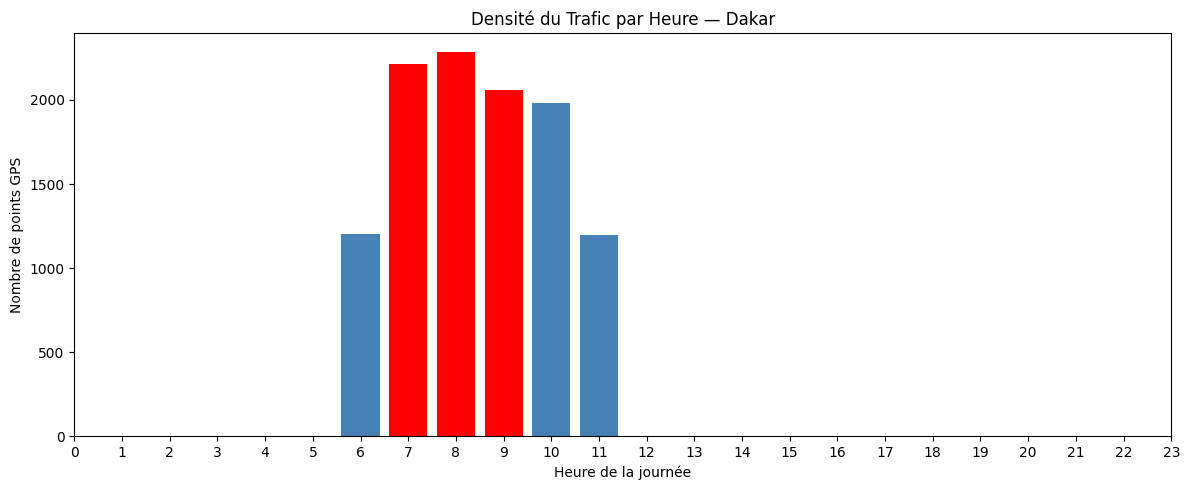

Graphique sauvegardé : trafic_par_heure.png


In [ ]:
# Densité de trafic par heure
print('=== Points GPS par heure ===')
df_heure = spark.sql('''
    SELECT heure, COUNT(*) as nb_points
    FROM trajets_enrichis
    GROUP BY heure
    ORDER BY heure
''')
df_heure.show(24)

# Graphique
pdf_heure = df_heure.toPandas()
plt.figure(figsize=(12, 5))
bars = plt.bar(pdf_heure['heure'], pdf_heure['nb_points'],
               color=['red' if h in [7,8,9,17,18,19] else 'steelblue'
                      for h in pdf_heure['heure']])
plt.xlabel('Heure de la journée')
plt.ylabel('Nombre de points GPS')
plt.title('Densité du Trafic par Heure — Dakar')
plt.xticks(range(0, 24))
plt.tight_layout()
plt.savefig('trafic_par_heure.png', dpi=150)
plt.show()
print('Graphique sauvegardé : trafic_par_heure.png')

In [ ]:
import os
from google.colab import files

def download_python_cells(cell_contents, filename_prefix='colab_script'):
    """
    Télécharge le contenu des cellules Python sous forme de fichiers .py.

    Args:
        cell_contents (list of tuple): Une liste de tuples (cell_id, code_content)
                                      pour les cellules à télécharger.
        filename_prefix (str): Préfixe pour les noms de fichiers.
    """
    for i, (cell_id, code) in enumerate(cell_contents):
        filename = f"{filename_prefix}_{cell_id}.py"
        with open(filename, 'w') as f:
            f.write(code)
        files.download(filename)
        print(f"Fichier {filename} téléchargé.")

# Exemple d'utilisation (vous devrez remplacer ceci par les cellules que vous voulez)
# Pour l'instant, je vais utiliser un exemple avec une seule cellule fictive.
# Vous devrez me donner les IDs des cellules que vous souhaitez télécharger.

# cells_to_download = [
#     ('cell_id_1', 'print("Code de la cellule 1")'),
#     ('cell_id_2', 'x = 10\ny = 20\nprint(x + y)')
# ]

# Si vous souhaitez télécharger des cellules spécifiques, veuillez me donner leurs IDs.
# Par exemple, si vous voulez télécharger les cellules 'H_Epwm0chHHk' et 'LnhjEN5zhUFB':
# cells_to_download = [
#     ('H_Epwm0chHHk', notebook_state['H_Epwm0chHHk']['content']),
#     ('LnhjEN5zhUFB', notebook_state['LnhjEN5zhUFB']['content'])
# ]

# Indiquez les IDs des cellules que vous souhaitez télécharger.
# Je peux vous aider à trouver le contenu de ces cellules si nécessaire.
# Pour le moment, je n'ai pas accès direct au contenu des cellules passées dans cet outil.
# Il faudra que je génère le code pour extraire le contenu des cellules spécifiques.


+-------------+---------+---------------+
|type_vehicule|nb_points|vitesse_moyenne|
+-------------+---------+---------------+
|  Particulier|     6345|          12.29|
|         Taxi|     3339|          13.14|
|          Bus|     1256|           12.8|
+-------------+---------+---------------+



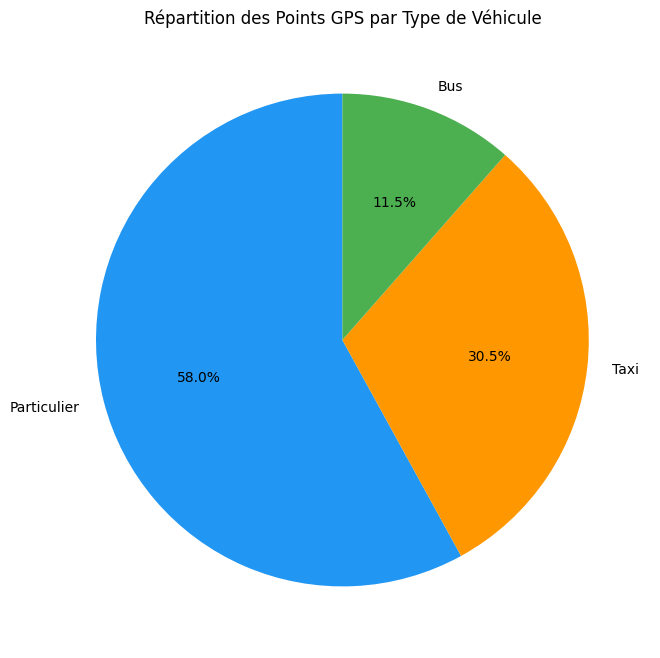

In [ ]:
# Répartition par type de véhicule
df_vehicules = spark.sql('''
    SELECT type_vehicule, COUNT(*) as nb_points,
           ROUND(AVG(vitesse_kmh), 2) as vitesse_moyenne
    FROM trajets_enrichis
    GROUP BY type_vehicule
    ORDER BY nb_points DESC
''')
df_vehicules.show()

# Graphique camembert
pdf_v = df_vehicules.toPandas()
plt.figure(figsize=(8, 8))
plt.pie(pdf_v['nb_points'], labels=pdf_v['type_vehicule'],
        autopct='%1.1f%%', startangle=90,
        colors=['#2196F3','#FF9800','#4CAF50'])
plt.title('Répartition des Points GPS par Type de Véhicule')
plt.savefig('repartition_vehicules.png', dpi=150)
plt.show()


+-------------+------------+----------------+-----------------+
|type_incident|nb_incidents|severite_moyenne|duree_moyenne_min|
+-------------+------------+----------------+-----------------+
|      Travaux|           6|            3.17|             55.9|
|     Accident|           4|            1.75|             85.5|
+-------------+------------+----------------+-----------------+



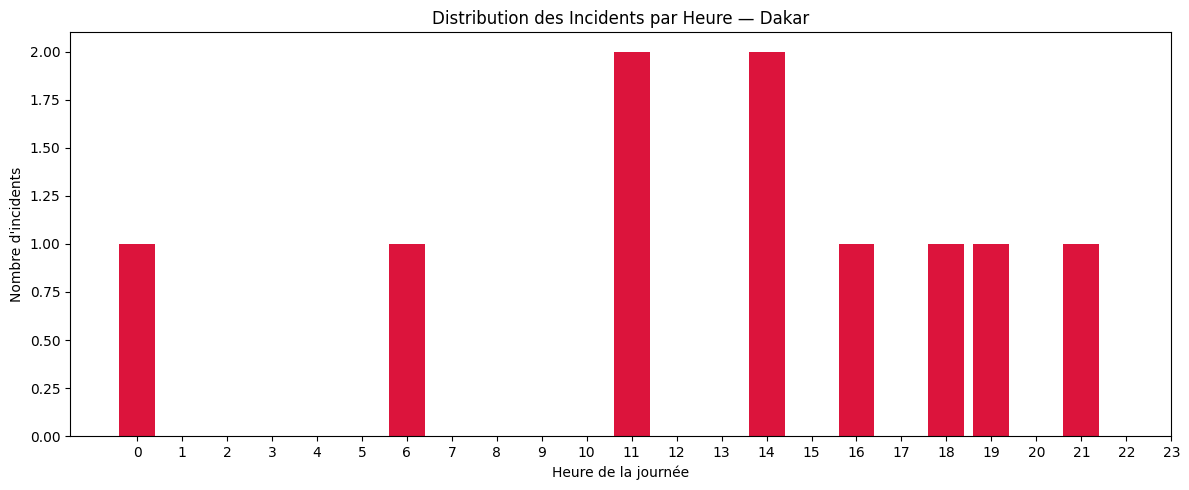

In [ ]:
# Incidents par type et sévérité
df_inc_analyse = spark.sql('''
    SELECT type_incident,
           COUNT(*) as nb_incidents,
           ROUND(AVG(severite), 2) as severite_moyenne,
           ROUND(AVG(duree_incident_min), 1) as duree_moyenne_min
    FROM incidents_enrichis
    GROUP BY type_incident
    ORDER BY nb_incidents DESC
''')
df_inc_analyse.show()

# Incidents par heure
df_inc_heure = spark.sql('''
    SELECT HOUR(timestamp_debut) as heure_debut,
           COUNT(*) as nb_incidents
    FROM incidents_enrichis
    GROUP BY HOUR(timestamp_debut)
    ORDER BY heure_debut
''')

pdf_ih = df_inc_heure.toPandas()
plt.figure(figsize=(12, 5))
plt.bar(pdf_ih['heure_debut'], pdf_ih['nb_incidents'], color='crimson')
plt.xlabel('Heure de la journée')
plt.ylabel('Nombre d\'incidents')
plt.title('Distribution des Incidents par Heure — Dakar')
plt.xticks(range(0, 24))
plt.tight_layout()
plt.savefig('incidents_par_heure.png', dpi=150)
plt.show()


In [ ]:
# Échantillon des trajets pour la carte
df_sample = spark.sql('''
    SELECT latitude, longitude, heure
    FROM trajets_enrichis
    TABLESAMPLE(1 PERCENT)
''')
pdf_sample = df_sample.toPandas()

# Créer la carte centrée sur Dakar
map_dakar = folium.Map(location=[14.7167, -17.4677], zoom_start=12)

# Ajouter la heatmap
heat_data = pdf_sample[['latitude', 'longitude']].values.tolist()
HeatMap(heat_data, radius=8, blur=10, max_zoom=13).add_to(map_dakar)

map_dakar.save('heatmap_trajets_dakar.html')
print('Carte sauvegardée : heatmap_trajets_dakar.html')

# Afficher dans Colab
from IPython.display import IFrame
IFrame('heatmap_trajets_dakar.html', width=700, height=400)

Carte sauvegardée : heatmap_trajets_dakar.html


In [ ]:
from google.colab import files
files.download('heatmap_trajets_dakar.html')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# **ÉTAPE 5 : Analyse des Flux et Patterns (Spark SQL)**

In [ ]:
# Assigner chaque point GPS à une zone de Dakar
DAKAR_ZONES = {
    'Plateau':     (14.66, 14.68, -17.44, -17.42),
    'Medina':      (14.68, 14.70, -17.46, -17.44),
    'Grand Dakar': (14.70, 14.72, -17.45, -17.43),
    'HLM':         (14.71, 14.73, -17.44, -17.42),
    'Yoff':        (14.74, 14.76, -17.49, -17.47),
    'Pikine':      (14.75, 14.77, -17.40, -17.38),
}

from pyspark.sql.functions import udf
from pyspark.sql.types import StringType

def get_zone(lat, lon):
    if lat is None or lon is None:
        return None
    for zone, (lat_min, lat_max, lon_min, lon_max) in DAKAR_ZONES.items():
        if lat_min <= lat <= lat_max and lon_min <= lon <= lon_max:
            return zone
    return 'Autre'

get_zone_udf = udf(get_zone, StringType())
spark.udf.register('get_zone_udf', get_zone, StringType())

df_with_zone = spark.sql('''
    SELECT *, get_zone_udf(latitude, longitude) as nom_zone
    FROM trajets_enrichis
''')
df_with_zone.createOrReplaceTempView('trajets_avec_zone')

# Densité par zone et heure
df_densite = spark.sql('''
    SELECT nom_zone, heure, COUNT(*) as nb_points
    FROM trajets_avec_zone
    WHERE nom_zone != 'Autre'
    GROUP BY nom_zone, heure
    ORDER BY nom_zone, heure
''')
df_densite.show(30, truncate=False)


+-----------+-----+---------+
|nom_zone   |heure|nb_points|
+-----------+-----+---------+
|Grand Dakar|6    |40       |
|Grand Dakar|7    |256      |
|Grand Dakar|8    |247      |
|Grand Dakar|9    |193      |
|Grand Dakar|10   |229      |
|Grand Dakar|11   |170      |
|HLM        |6    |38       |
|HLM        |7    |164      |
|HLM        |8    |197      |
|HLM        |9    |165      |
|HLM        |10   |46       |
|HLM        |11   |138      |
|Medina     |6    |154      |
|Medina     |7    |548      |
|Medina     |8    |437      |
|Medina     |9    |549      |
|Medina     |10   |374      |
|Medina     |11   |378      |
|Pikine     |6    |244      |
|Pikine     |7    |392      |
|Pikine     |8    |471      |
|Pikine     |9    |367      |
|Pikine     |10   |478      |
|Pikine     |11   |87       |
|Plateau    |6    |261      |
|Plateau    |7    |317      |
|Plateau    |8    |267      |
|Plateau    |9    |187      |
|Plateau    |10   |299      |
|Plateau    |11   |136      |
+---------

+-----------+------------+-----------+
|   nom_zone|total_points|vitesse_moy|
+-----------+------------+-----------+
|     Medina|        2440|       12.5|
|       Yoff|        2250|        3.5|
|     Pikine|        2039|       22.6|
|    Plateau|        1467|        3.5|
|Grand Dakar|        1135|       25.0|
|        HLM|         748|       22.6|
+-----------+------------+-----------+



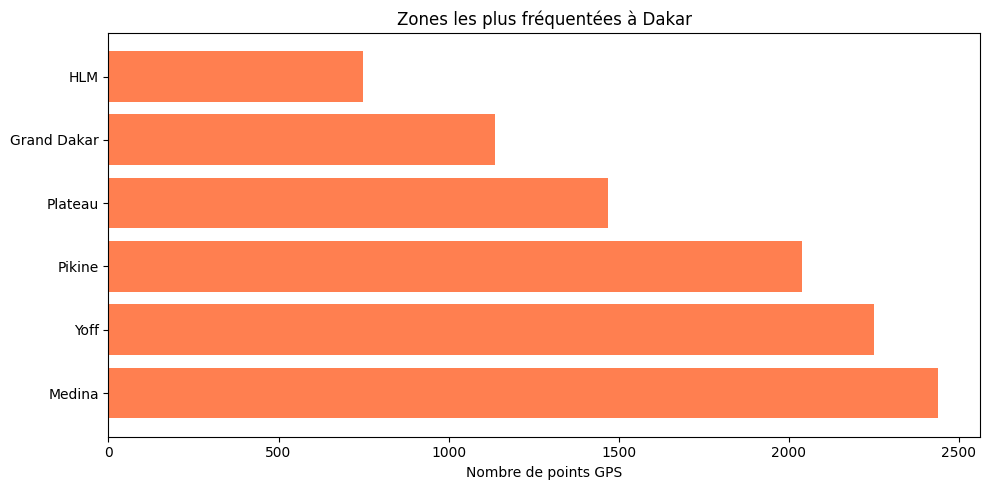

In [ ]:
df_top_zones = spark.sql('''
    SELECT nom_zone,
           COUNT(*) as total_points,
           ROUND(AVG(vitesse_kmh), 1) as vitesse_moy
    FROM trajets_avec_zone
    WHERE nom_zone != 'Autre'
    GROUP BY nom_zone
    ORDER BY total_points DESC
''')
df_top_zones.show()

# Graphique barres horizontales
pdf_zones = df_top_zones.toPandas()
plt.figure(figsize=(10, 5))
plt.barh(pdf_zones['nom_zone'], pdf_zones['total_points'], color='coral')
plt.xlabel('Nombre de points GPS')
plt.title('Zones les plus fréquentées à Dakar')
plt.tight_layout()
plt.savefig('zones_frequentees.png', dpi=150)
plt.show()
